# PBMC 3k end-to-end, on a pure scrust stack

The single-cell clustering walkthrough for PBMC 3k, built entirely on **scrust** — no scanpy
is imported anywhere in this notebook:

* computation is `scrust` (`sr.pp`, `sr.tl`) on the Apple GPU (Metal via candle, plus the
  hand-written `knn` kernel behind `pp.neighbors`),
* the data is fetched from **10x Genomics** and read with `anndata` directly, and
* every figure is drawn by the native `scrust.pl` (`sr.pl`) module — publication-grade
  matplotlib/seaborn.

This file is the source: it is a real notebook, not generated from a script. The last cell
proves the run never imported scanpy (`sys.modules` check).

## Step 0 — Repository path setup

Find the repo root (the folder with `pyproject.toml`) from the working directory and put its
`python/` on `sys.path`, so `import scrust` works wherever the notebook is launched from.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
repo_root = next((p for p in (_here, *_here.parents) if (p / "pyproject.toml").exists()), _here)
if str(repo_root / "python") not in sys.path:
    sys.path.insert(0, str(repo_root / "python"))
print(f"repo root: {repo_root}")

repo root: /Users/Shared/runDE


## Step 1 — Imports and Metal GPU availability

`scrust` mirrors the module layout a single-cell user expects (`pp`, `tl`, `pl`). `%matplotlib
inline` renders the `sr.pl` figures straight into the notebook. `sr.gpu_available()` reports
whether Metal came up — when it did, `device="auto"` runs the device-aware steps on the GPU.

In [2]:
%matplotlib inline

import anndata

import scrust as sr

FIGURE_DIR = repo_root / "docs" / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"scrust {sr.__version__} | Metal GPU available: {sr.gpu_available()}")

scrust 0.2.0 | Metal GPU available: True


## Step 2 — Load PBMC 3k (10x Genomics, no scanpy)

Read a cached `.h5ad` if present, otherwise fetch the 10x filtered matrix and assemble it into
an `AnnData` with `scipy` + `anndata`. This is the same 2 700-cell raw matrix the classic
tutorial uses, obtained without importing scanpy.

In [3]:
def load_pbmc3k(cache_dir):
    """Raw PBMC 3k as an AnnData, from a local .h5ad cache or the 10x Genomics matrix."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    h5ad = cache_dir / "pbmc3k_raw.h5ad"
    if h5ad.exists():
        return anndata.read_h5ad(h5ad)

    # Portable fallback: fetch and assemble the 10x filtered matrix (no scanpy involved).
    import tarfile
    import urllib.request

    import pandas as pd
    from scipy.io import mmread

    url = "https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
    archive = cache_dir / "pbmc3k_10x.tar.gz"
    if not archive.exists():
        print(f"downloading {url}")
        urllib.request.urlretrieve(url, archive)
    with tarfile.open(archive) as tar:
        tar.extractall(cache_dir)
    base = cache_dir / "filtered_gene_bc_matrices" / "hg19"
    counts = mmread(base / "matrix.mtx").T.tocsr().astype("float32")  # cells x genes
    barcodes = pd.read_csv(base / "barcodes.tsv", header=None)[0].to_numpy()
    symbols = pd.read_csv(base / "genes.tsv", sep="\t", header=None)[1].to_numpy()
    adata = anndata.AnnData(
        X=counts,
        obs=pd.DataFrame(index=barcodes),
        var=pd.DataFrame(index=symbols),
    )
    adata.write_h5ad(h5ad)
    return adata


adata = load_pbmc3k(repo_root / ".cache" / "pbmc3k")
adata.var_names_make_unique()
print(f"loaded {adata.n_obs} cells x {adata.n_vars} genes")

loaded 2700 cells x 32738 genes


## Step 3 — Quality control and filtering

Flag mitochondrial genes (a boolean column of `var`), then `sr.pp.calculate_qc_metrics` fills
the per-cell QC columns. Cells and genes are filtered with `sr.pp.filter_cells` /
`sr.pp.filter_genes`; the mitochondrial-fraction cut is plain AnnData boolean indexing.

In [4]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sr.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

sr.pp.filter_cells(adata, min_genes=200)
sr.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 5].copy()
print(f"after QC: {adata.n_obs} cells x {adata.n_vars} genes")

after QC: 2643 cells x 13714 genes


## Step 4 — Normalisation and log transform

Counts-per-10k normalisation followed by `log1p`. `adata.raw` keeps the full log-normalised
matrix, which the differential-expression and gene plots read back later.

In [5]:
sr.pp.normalize_total(adata, target_sum=1e4)
sr.pp.log1p(adata)
adata.raw = adata

## Step 5 — Highly variable genes and scaling

Select the 2000 most variable genes (Seurat flavour), subset to them, then z-score each gene
with `sr.pp.scale`. Scaling densifies, so subsetting to HVGs first keeps it small.

In [6]:
sr.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"].to_numpy()].copy()
sr.pp.scale(adata, zero_center=True, max_value=10)
print(f"kept {adata.n_vars} highly variable genes")

kept 2000 highly variable genes


## Step 6 — PCA

Truncated PCA (randomised SVD, on the GPU). Writes `obsm["X_pca"]`, `varm["PCs"]` and
`uns["pca"]`, which `sr.pl.pca_variance_ratio` reads.

In [7]:
sr.pp.pca(adata, n_comps=50, random_state=0)
print(f"obsm['X_pca'] {adata.obsm['X_pca'].shape}")

obsm['X_pca'] (2643, 50)


## Step 7 — k-NN graph, with the Metal GPU kernel

`device="auto"` routes the k-NN search to the hand-written `knn` Metal kernel on Apple silicon
(the first scrust GPU kernel on the call path), and to the candle CPU path otherwise. Both
produce the same neighbour graph. Writes `obsp["distances"]`, `obsp["connectivities"]`,
`uns["neighbors"]`.

In [8]:
sr.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", device="auto")
print(f"neighbour graph on {adata.n_obs} cells (device='auto')")

neighbour graph on 2643 cells (device='auto')


## Step 8 — Clustering and UMAP embedding

Leiden clustering over the neighbour graph, then a UMAP layout. `sr.tl.leiden` writes
`obs["leiden"]` and `sr.tl.umap` writes `obsm["X_umap"]`.

In [9]:
sr.tl.leiden(adata, resolution=1.0, key_added="leiden")
sr.tl.umap(adata, random_state=0)
n_clusters = adata.obs["leiden"].nunique()
print(f"{n_clusters} Leiden clusters; obsm['X_umap'] {adata.obsm['X_umap'].shape}")

10 Leiden clusters; obsm['X_umap'] (2643, 2)


## Step 9 — Differential expression (marker genes)

Rank marker genes per cluster with the Wilcoxon rank-sum test on the **log-normalised** matrix
(from `adata.raw`), not the scaled one, because fold changes on z-scored data are meaningless.

In [10]:
ranked = adata.raw.to_adata()[:, adata.var_names].copy()
ranked.obs["leiden"] = adata.obs["leiden"]
sr.tl.rank_genes_groups(ranked, "leiden", method="wilcoxon")
top = ranked.uns["rank_genes_groups"]["names"][0]
print(f"top marker per cluster: {list(top)}")

top marker per cluster: ['RPL13', 'LTB', 'S100A9', 'CD74', 'CCL5', 'LST1', 'NKG7', 'HLA-DPA1', 'PF4', 'KIAA0101']


## Step 10 — Visualisation with the native `sr.pl` module

Four publication-grade figures, drawn by `scrust.pl` and rendered inline: the PCA elbow, the
UMAP by Leiden cluster (categorical, seaborn `husl`), the UMAP by a marker gene (continuous
`viridis`, from `adata.raw`), and the marker-gene ranking per cluster.

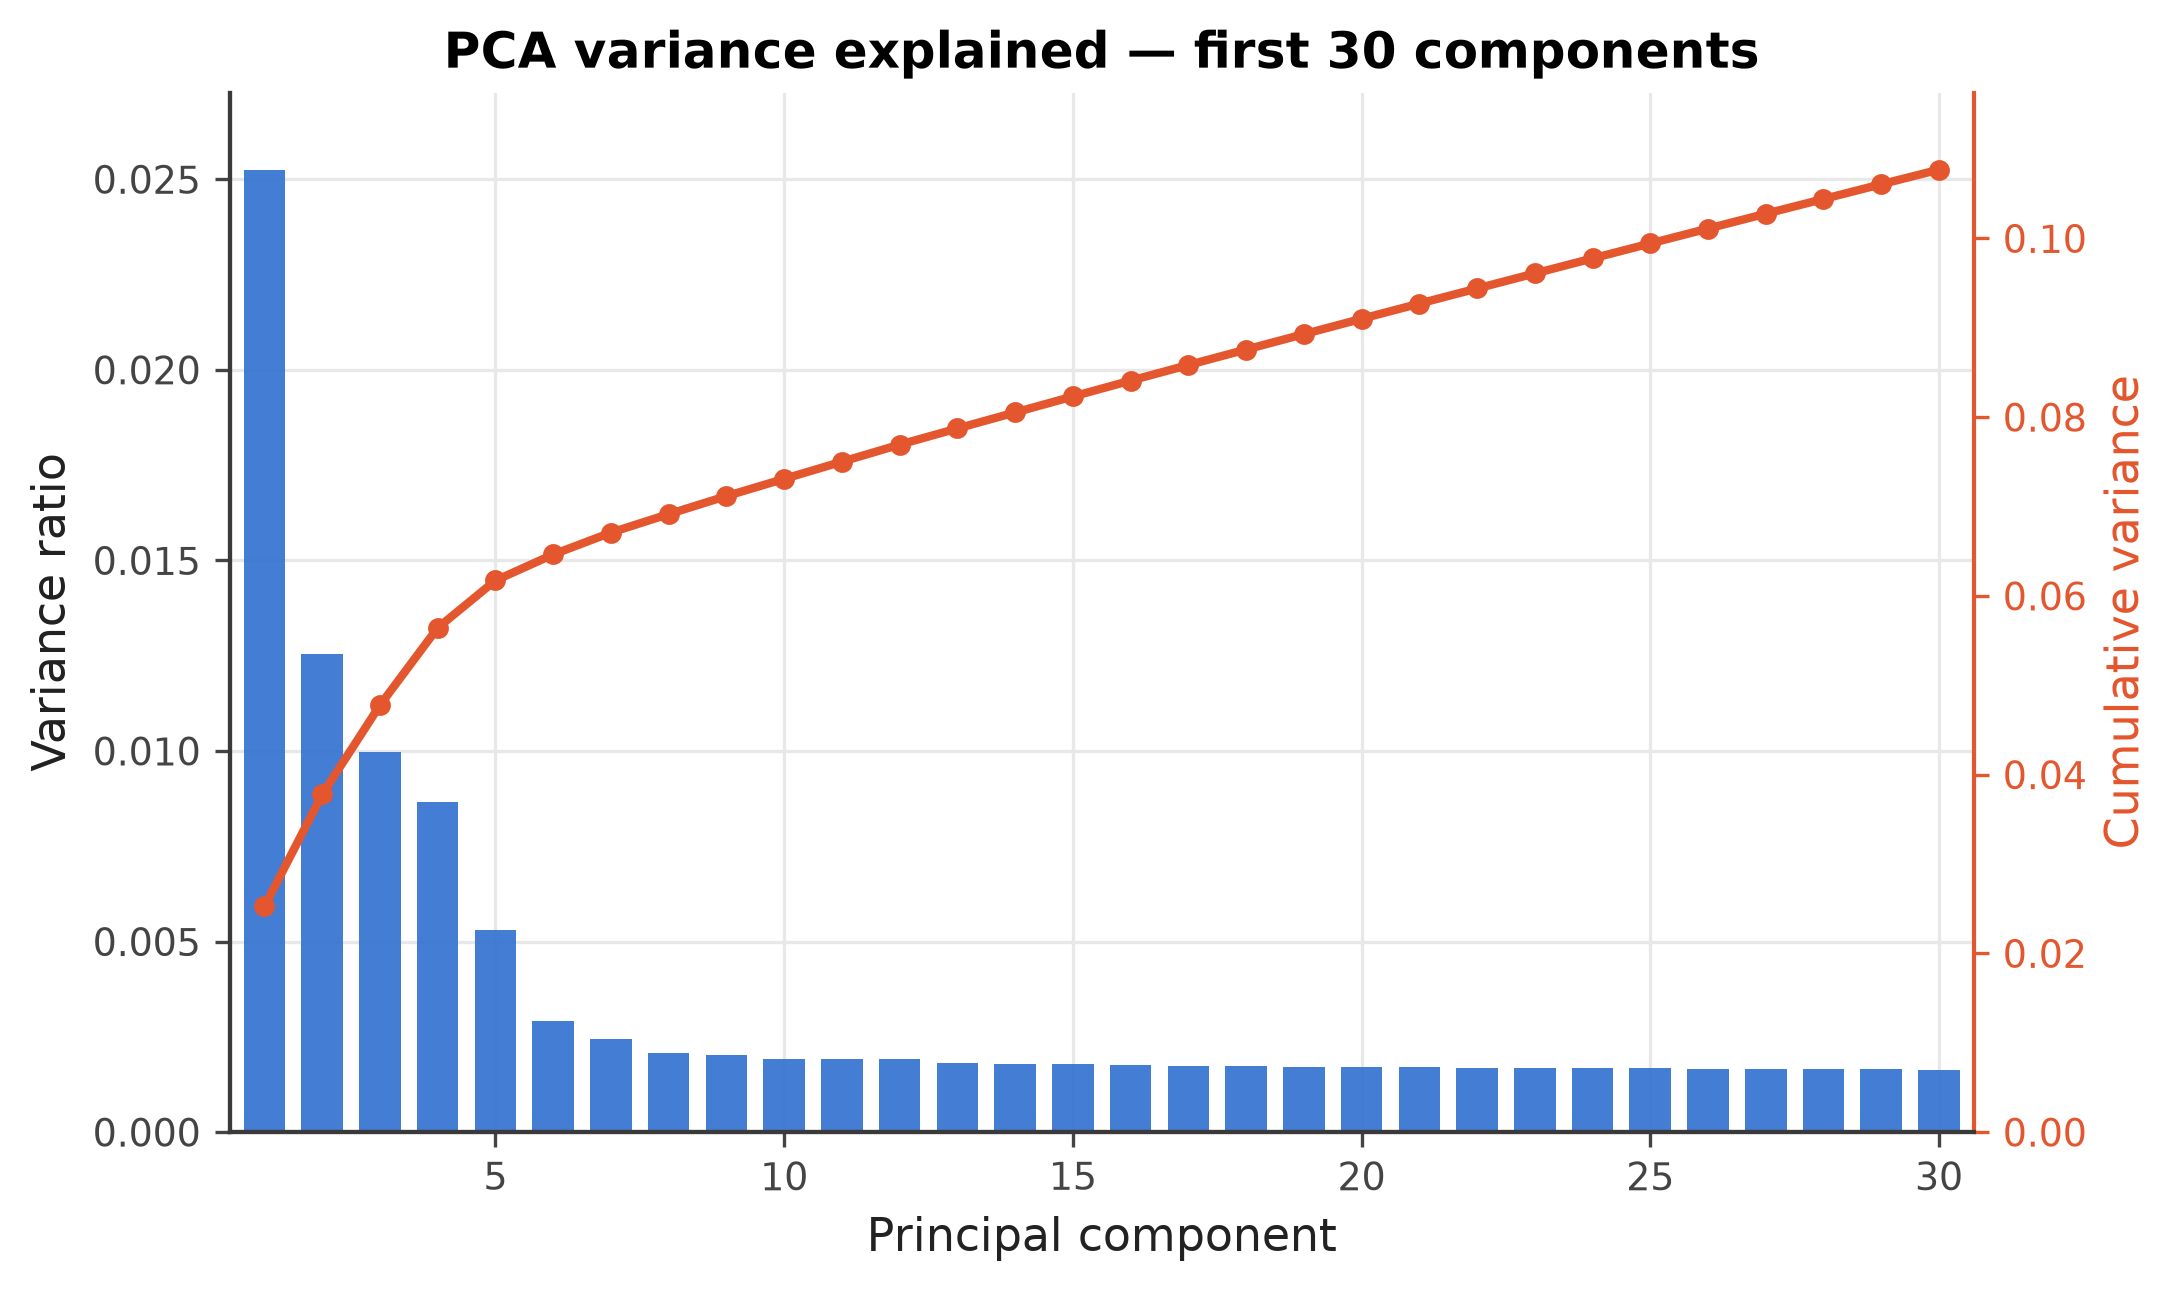

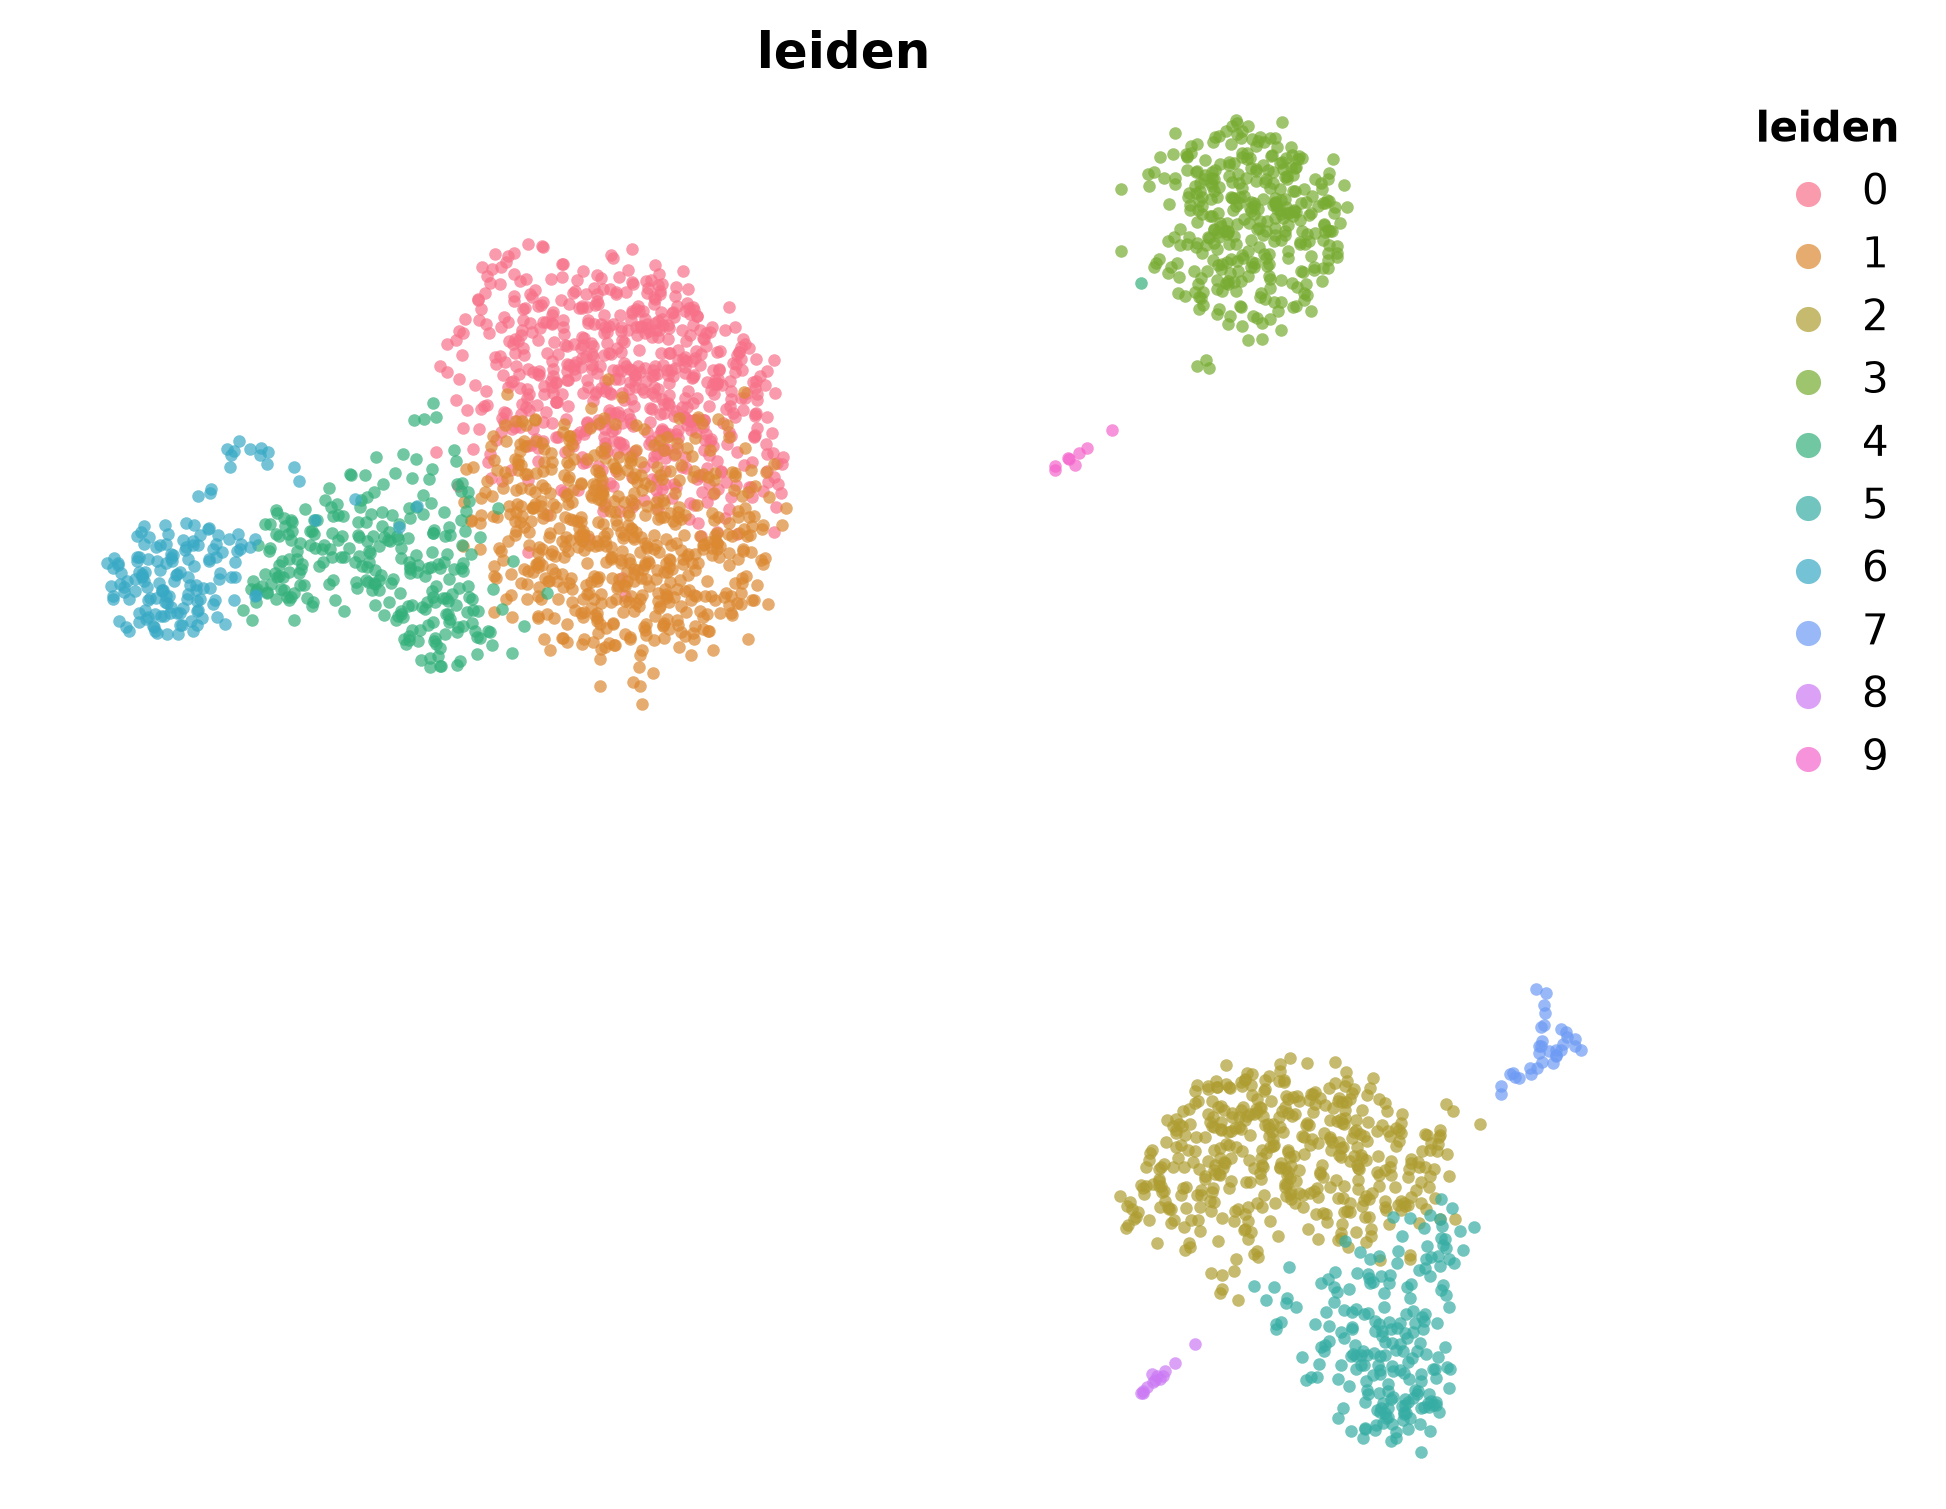

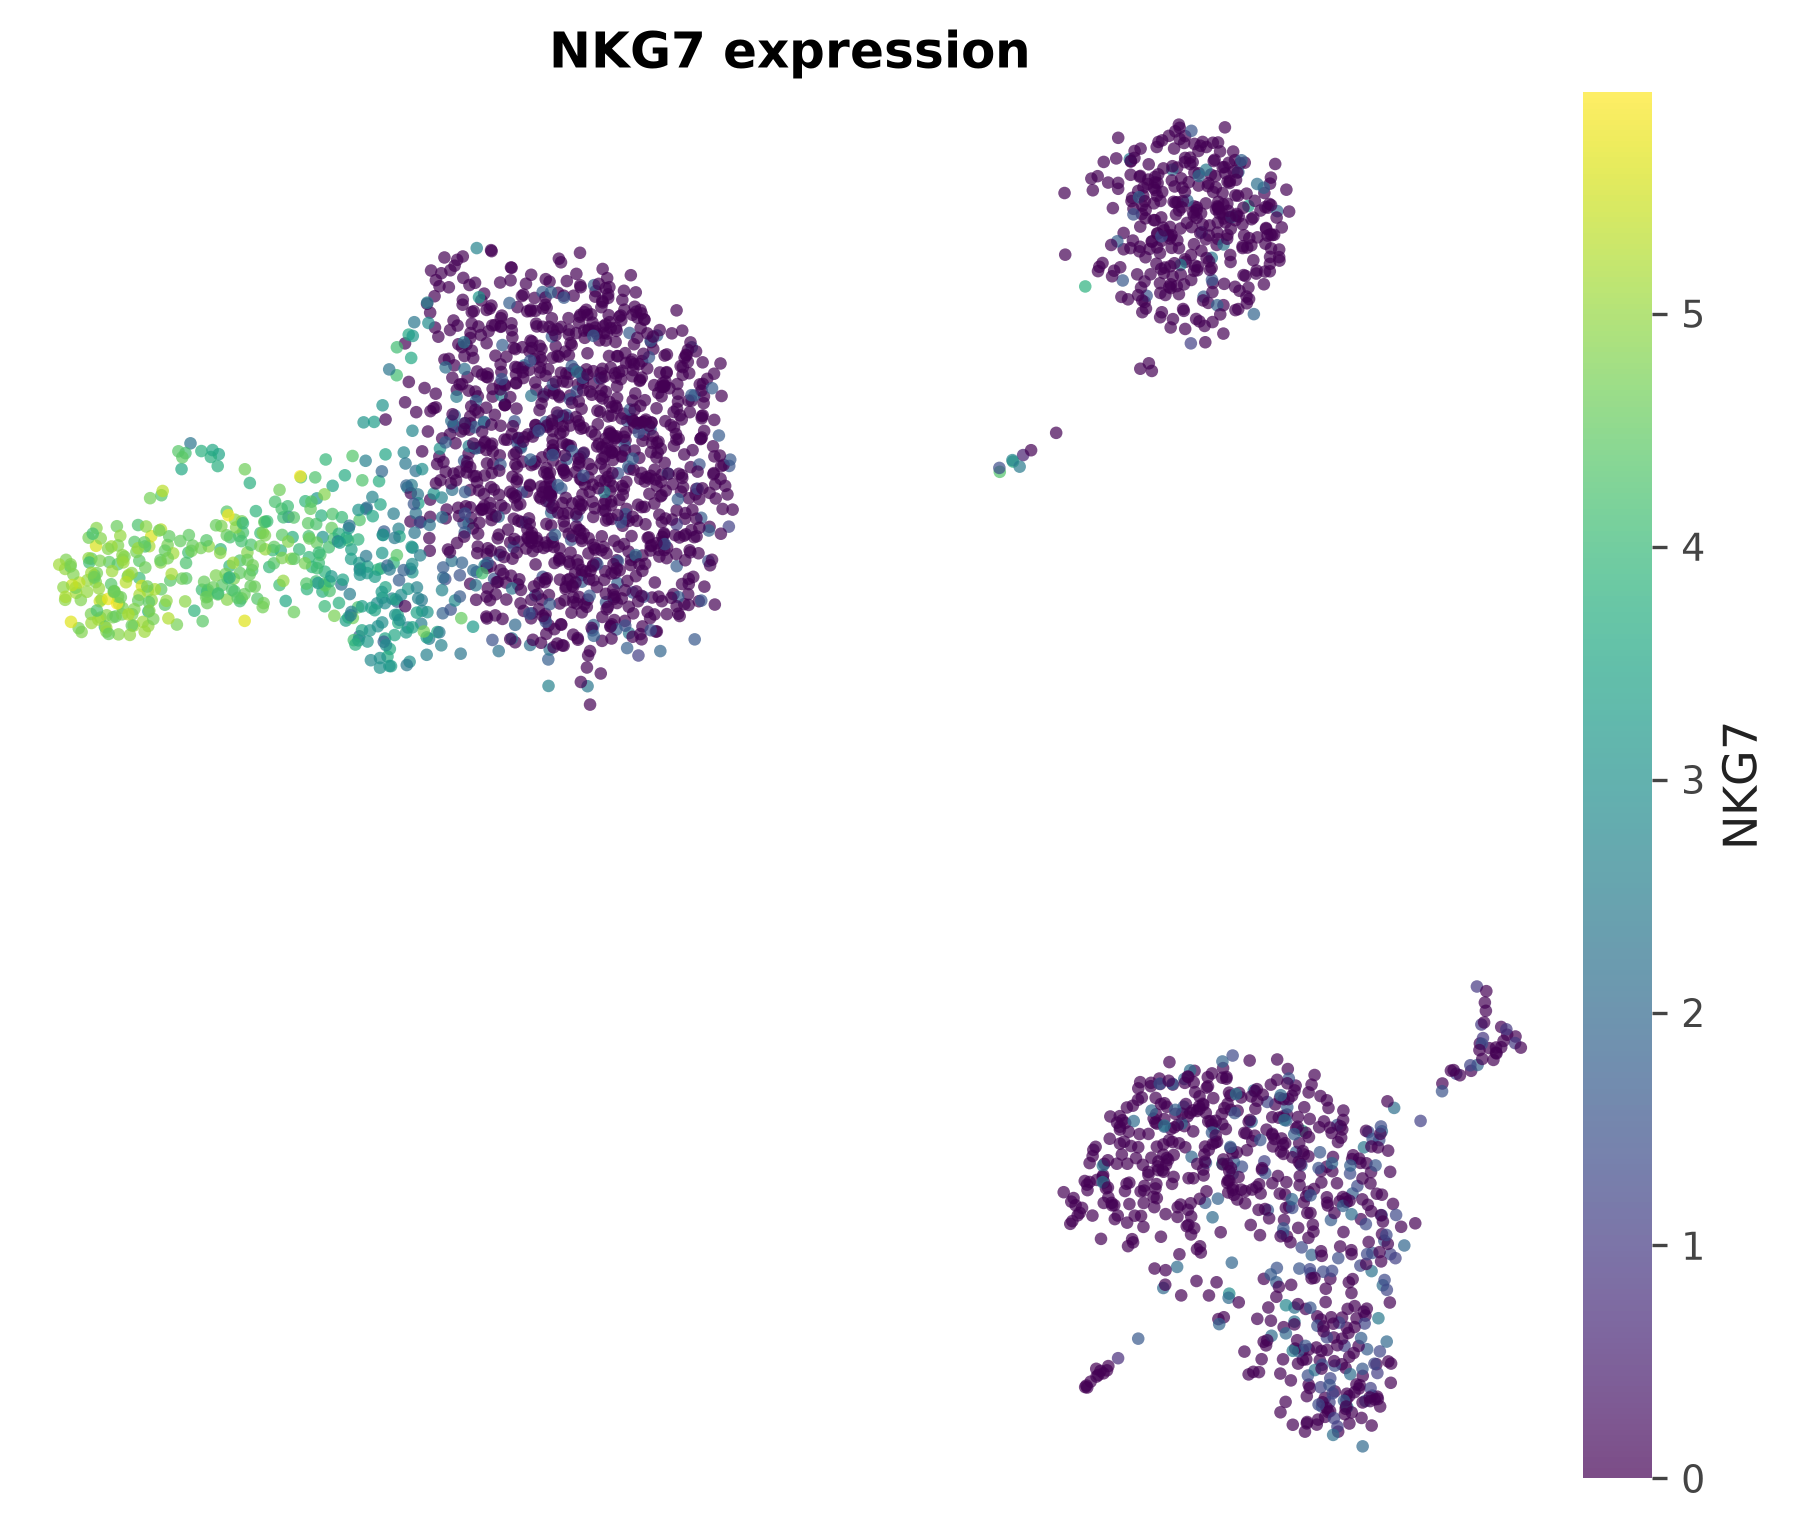

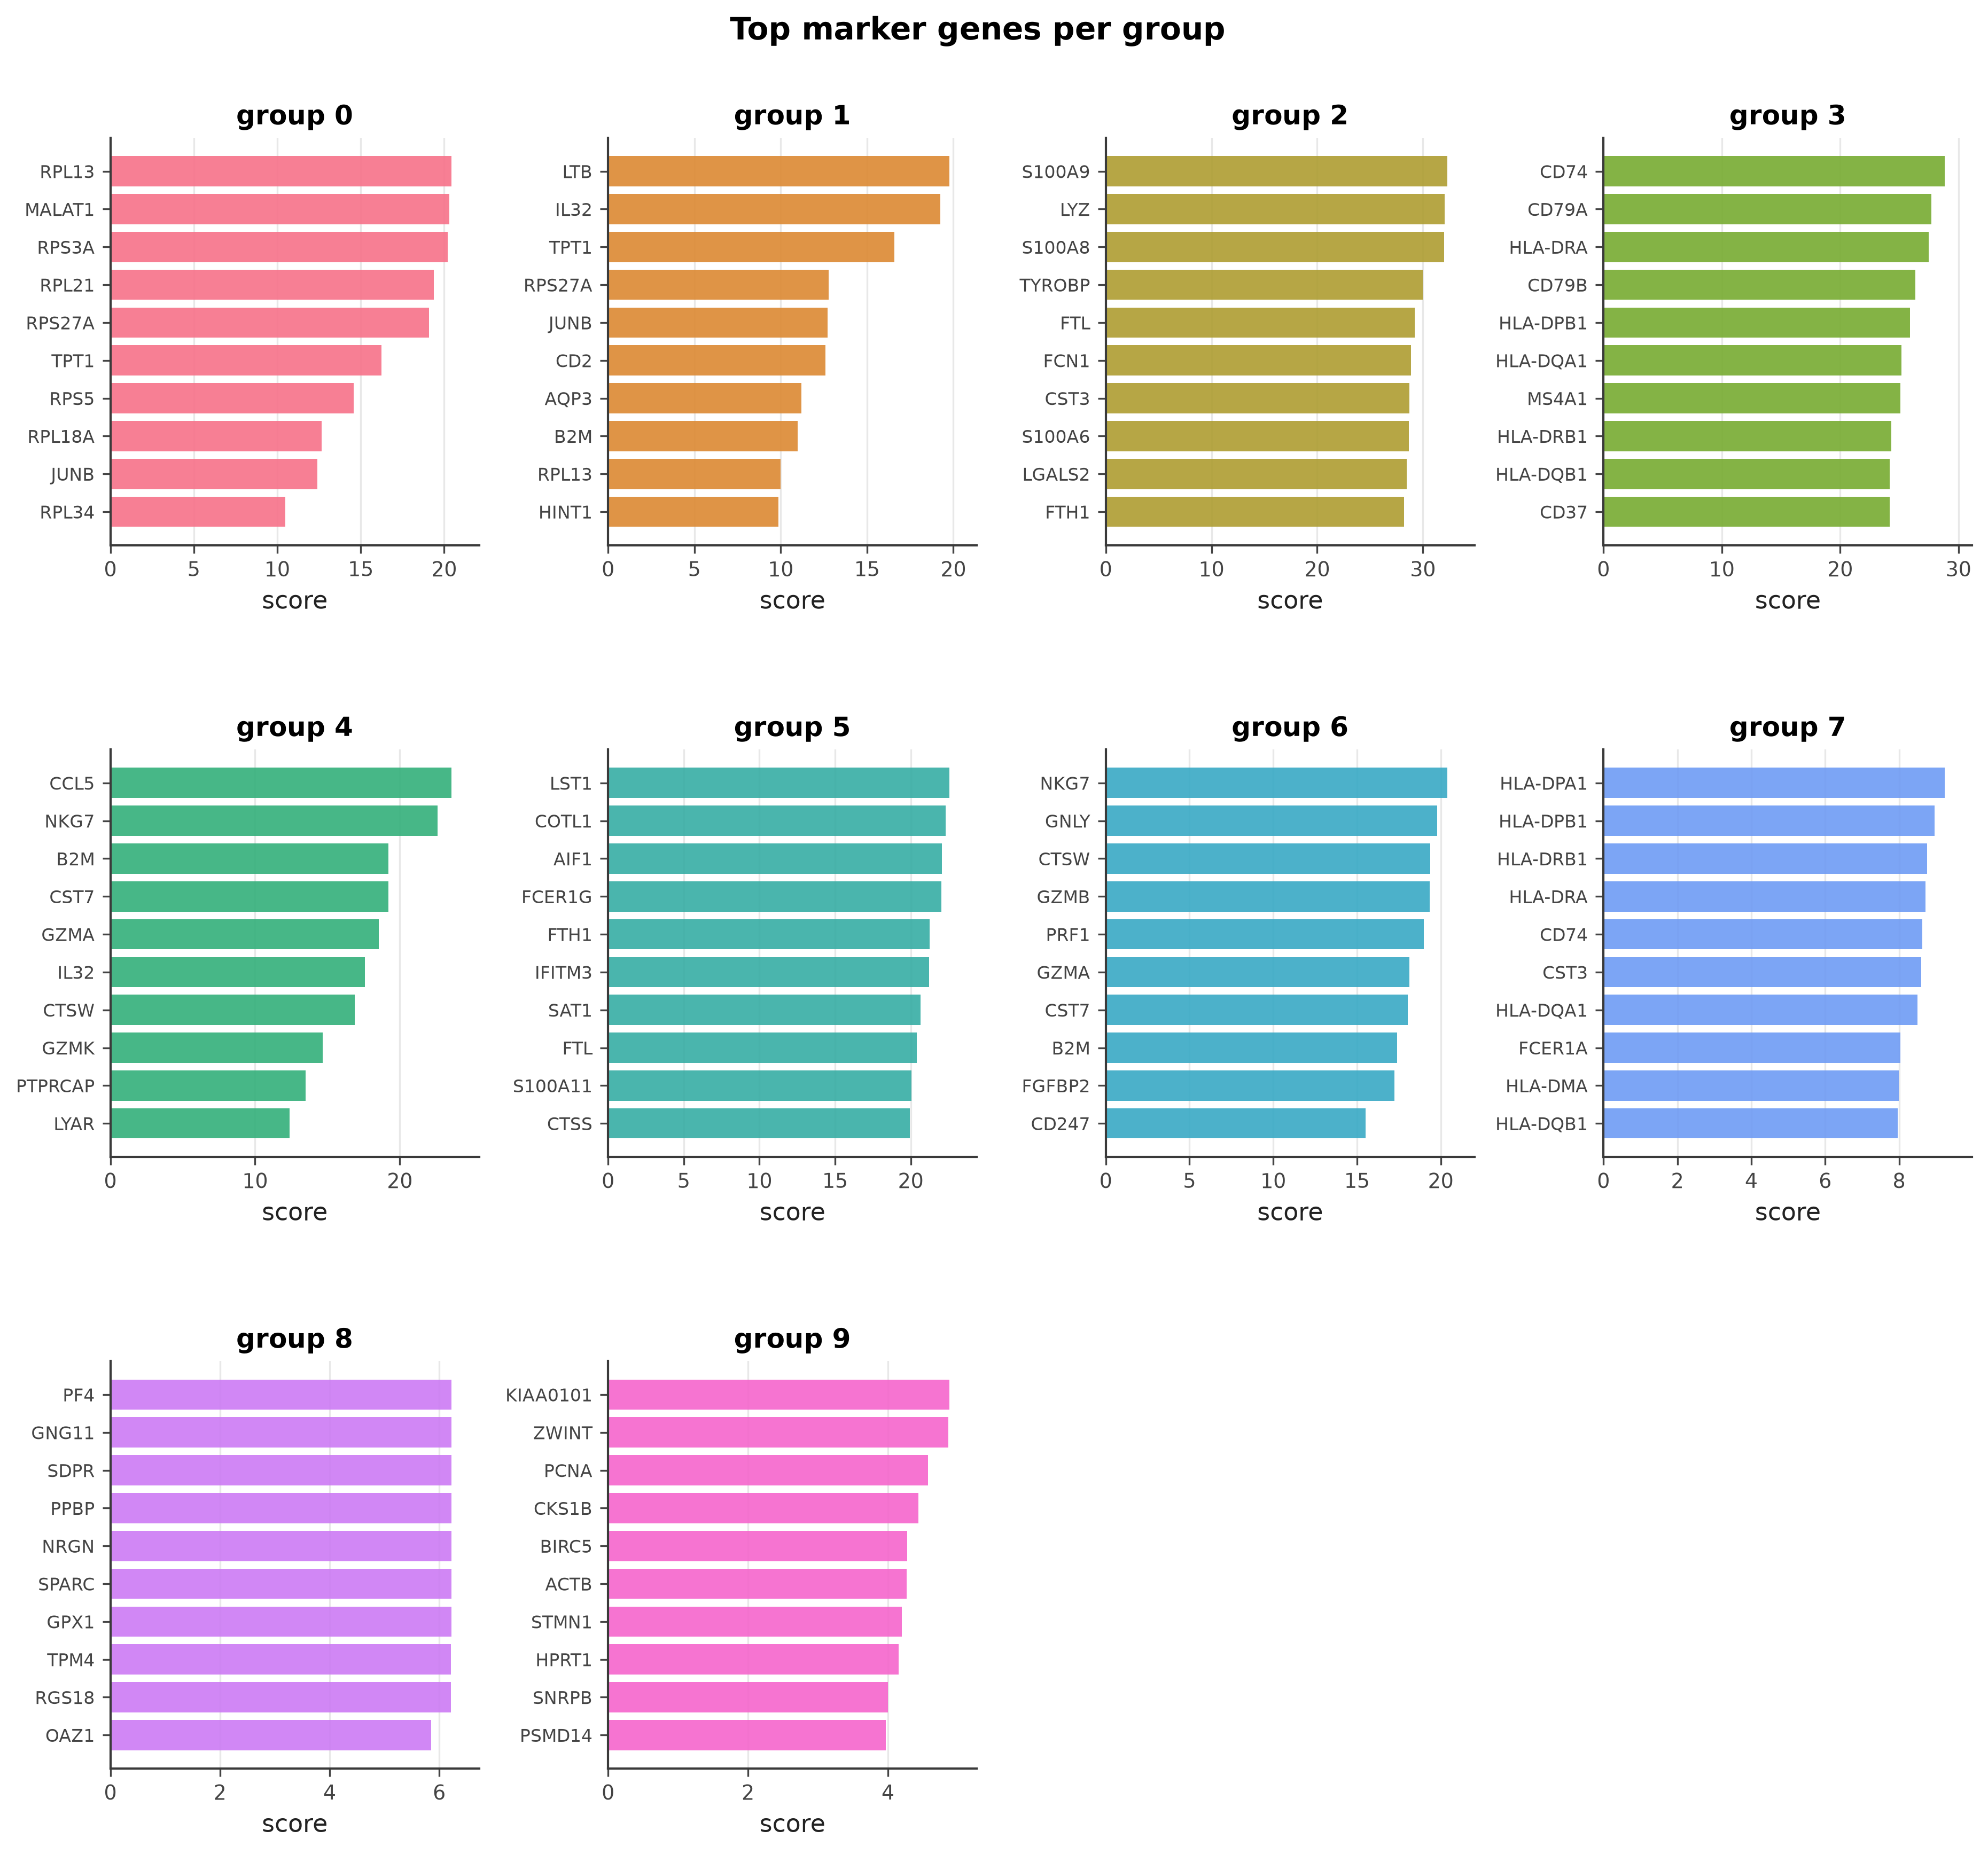

coloured UMAP marker gene: NKG7


In [11]:
marker = next(
    (g for g in ("NKG7", "CST3", "MS4A1", "PPBP") if g in adata.raw.var_names),
    adata.raw.var_names[0],
)

sr.pl.pca_variance_ratio(adata, n_pcs=30, save=FIGURE_DIR / "pca_variance_ratio.png")
sr.pl.umap(adata, color="leiden", save=FIGURE_DIR / "umap_leiden.png")
sr.pl.umap(adata, color=marker, title=f"{marker} expression", save=FIGURE_DIR / "umap_gene.png")
sr.pl.rank_genes_groups(ranked, n_genes=10, n_cols=4, save=FIGURE_DIR / "rank_genes_groups.png")
print(f"coloured UMAP marker gene: {marker}")

## Verification — the run never imported scanpy

A runtime proof stronger than a source grep: after the whole pipeline, loader and plotting have
run, scanpy is not among the imported modules.

In [12]:
assert "scanpy" not in sys.modules, "scanpy was imported somewhere in this notebook"
print("verified: scanpy was never imported during this run")
print("loaded modules of interest:", sorted(
    m for m in sys.modules if m in {"scrust", "anndata", "matplotlib", "seaborn", "scipy"}
))

verified: scanpy was never imported during this run
loaded modules of interest: ['anndata', 'matplotlib', 'scipy', 'scrust', 'seaborn']
